<a href="https://colab.research.google.com/github/andresalmanzal/tfm-siniestros-bogota/blob/main/notebooks/tfm_siniestros_bogota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM - Predicción de gravedad y mapa de riesgo de siniestros viales en Bogotá
**Autor:** Ovidio Almanza Ledesma · Máster en Data Science, Big Data & Business Analytics (UCM)

Notebook único y autocontenido: descarga sus propios datos y se ejecuta de principio a fin en cualquier entorno con internet. Secciones:
1. **Carga, EDA y diseño de validación**
2. **Enriquecimiento** con tablas relacionales
3. **Features** adicionales (temporales, espaciales H3, interacciones)

### Problema de negocio
Las autoridades de movilidad de Bogotá operan con presupuesto limitado (marco *Visión Cero*):
> **¿Dónde, cuándo y bajo qué condiciones es más probable un siniestro vial *grave*, para priorizar intervenciones?**

### Enfoque (híbrido)
1. Modelo supervisado de **gravedad** del siniestro, interpretado con SHAP.
2. **Productivización**: mapa de riesgo por zona, mes y día de la semana.

### Fuentes y licencia
- *Histórico Siniestros Bogotá D.C.* (capa de puntos, API Esri REST) y *Siniestros Viales Consolidados* (Excel relacional). Secretaría Distrital de Movilidad — Datos Abiertos Bogotá. Licencia **CC BY 4.0**.

In [1]:
# Configuración e imports
import io, time, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 140)
for d in ["data/raw", "data/processed"]:
    Path(d).mkdir(parents=True, exist_ok=True)
print("Entorno listo. pandas", pd.__version__)

Entorno listo. pandas 2.2.2


---
## 1. Carga, EDA y diseño de validación

### Carga reproducible (capa de puntos)
Descarga paginada vía API Esri REST (estable, sin archivos frágiles), con caché y respaldo de subida manual. Ejecuta sin configuración previa.

In [2]:
ARCGIS_URL = ("https://services2.arcgis.com/NEwhEo9GGSHXcRXV/arcgis/rest/"
              "services/HistoricoSiniestros/FeatureServer/0/query")
CACHE_PTS = Path("data/raw/historico_siniestros.parquet")

def _descargar_arcgis(url=ARCGIS_URL, page=2000, max_paginas=2000):
    regs, off = [], 0
    for _ in range(max_paginas):
        params = {"where":"1=1","outFields":"*","returnGeometry":"true","outSR":4326,
                  "f":"json","resultOffset":off,"resultRecordCount":page,"orderByFields":"OBJECTID"}
        r = requests.get(url, params=params, timeout=60); r.raise_for_status()
        feats = r.json().get("features", [])
        if not feats: break
        for ft in feats:
            a = dict(ft.get("attributes", {})); g = ft.get("geometry") or {}
            a["GEOM_LON"], a["GEOM_LAT"] = g.get("x"), g.get("y"); regs.append(a)
        off += len(feats)
        if len(feats) < page: break
    if not regs: raise RuntimeError("ArcGIS no devolvió registros.")
    return pd.DataFrame(regs)

def cargar_puntos(forzar=False):
    if CACHE_PTS.exists() and not forzar:
        print(f"[cache] {CACHE_PTS}"); return pd.read_parquet(CACHE_PTS)
    print("[descarga] capa de puntos (ArcGIS)...")
    d = _descargar_arcgis()
    try: d.to_parquet(CACHE_PTS, index=False)
    except Exception: d.to_csv(CACHE_PTS.with_suffix(".csv"), index=False)
    print(f"Filas: {len(d):,} | Columnas: {d.shape[1]}")
    return d

df_raw = cargar_puntos()
df_raw.head(2)

[descarga] capa de puntos (ArcGIS)...
Filas: 209,861 | Columnas: 19


,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA_ACC,ANO_OCURRENCIA_ACC,DIRECCION,GRAVEDAD,CLASE_ACC,LOCALIDAD,FECHA_HORA_ACC,LATITUD,LONGITUD,CIV,PK_CALZADA,FECHA,HORA,FECHA_HORA,GEOM_LON,GEOM_LAT
0,631773,A000405746,4453111,1470096000000,2016,KR 10-CL 11 S 02,SOLO DANOS,CHOQUE,SAN CRISTOBAL,1470096000000,4.582107,-74.089798,4000156,241544,2/08/2016,2/08/2016,None,-74.089798,4.582107
1,631774,A000759671,4509563,1519344000000,2018,AV AVENIDA DE LAS AMERICAS-KR 68 2,SOLO DANOS,CHOQUE,PUENTE ARANDA,1519344000000,4.628828,-74.122387,16004636,169764,23/02/2018,23/02/2018,None,-74.122387,4.628828


### Control de calidad temporal
Verificamos si existe hora del día. (Resultado conocido: la capa de puntos **no** trae hora —cae a medianoche—; la recuperaremos en la Sección 2 desde el Excel consolidado.)

In [3]:
for c in ["FECHA_OCURRENCIA_ACC", "FECHA_HORA_ACC"]:
    h = pd.to_datetime(pd.to_numeric(df_raw[c], errors="coerce"), unit="ms", errors="coerce").dt.hour
    print(f"{c} -> % a las 00:00 = {(h==0).mean()*100:.1f}")
print("HORA (texto) no nula:", round(df_raw['HORA'].notna().mean()*100, 3), "%")

FECHA_OCURRENCIA_ACC -> % a las 00:00 = 100.0
FECHA_HORA_ACC -> % a las 00:00 = 100.0
HORA (texto) no nula: 0.001 %


### Saneamiento defensivo
Coerción numérica explícita, normalización de texto con `unicodedata`, mapeo explícito de la gravedad y parser de fechas robusto (epoch ms). Creamos `es_grave` (1 = "Con muertos"). No se asumen dtypes ni se borran filas.

In [4]:
def normalizar_texto(serie):
    def _n(x):
        if pd.isna(x): return np.nan
        s = unicodedata.normalize("NFKD", str(x).strip().upper())
        s = "".join(c for c in s if not unicodedata.combining(c)); s = " ".join(s.split())
        return s if s else np.nan
    return serie.map(_n)

def parse_fecha(serie):
    s = pd.to_numeric(serie, errors="coerce")
    if s.notna().mean() > 0.5 and s.dropna().abs().median() > 1e10:
        return pd.to_datetime(s, unit="ms", errors="coerce")
    return pd.to_datetime(serie, errors="coerce")

df = df_raw.copy()
for col in ["GRAVEDAD","CLASE_ACC","LOCALIDAD"]:
    df[col+"_norm"] = normalizar_texto(df[col])
MAP_G = {"SOLO DANOS":"Solo daños","CON HERIDOS":"Con heridos","CON MUERTOS":"Con muertos"}
df["gravedad"] = df["GRAVEDAD_norm"].map(MAP_G)
df["es_grave"] = (df["gravedad"]=="Con muertos").astype("Int64")
df["lat"] = pd.to_numeric(df["LATITUD"], errors="coerce").fillna(pd.to_numeric(df["GEOM_LAT"], errors="coerce"))
df["lon"] = pd.to_numeric(df["LONGITUD"], errors="coerce").fillna(pd.to_numeric(df["GEOM_LON"], errors="coerce"))
df["fecha_hora"] = parse_fecha(df["FECHA_HORA_ACC"])
df["anio"] = pd.to_numeric(df["ANO_OCURRENCIA_ACC"], errors="coerce").fillna(df["fecha_hora"].dt.year).astype("Int64")
df["mes"] = df["fecha_hora"].dt.month
df["dia_semana"] = df["fecha_hora"].dt.dayofweek
df["CODIGO_ACCIDENTE"] = pd.to_numeric(df["CODIGO_ACCIDENTE"], errors="coerce").astype("Int64")
print("Base saneada:", df.shape)

Base saneada: (209861, 30)


### EDA - target, clase, tiempo y espacio

In [5]:
# Target (desbalance) y clase x gravedad
print(pd.concat([df["gravedad"].value_counts().rename("conteo"),
                 (df["gravedad"].value_counts(normalize=True)*100).round(2).rename("%")], axis=1))
print("\nGravedad por clase (% fila):")
print((pd.crosstab(df["CLASE_ACC_norm"], df["gravedad"], normalize="index")*100).round(1))

             conteo      %
gravedad                  
Solo daños   134812  64.24
Con heridos   71656  34.14
Con muertos    3393   1.62

Gravedad por clase (% fila):
gravedad           Con heridos  Con muertos  Solo daños
CLASE_ACC_norm                                         
ATROPELLO                 92.5          7.2         0.2
AUTOLESION               100.0          0.0         0.0
CAIDA DE OCUPANTE         98.8          0.8         0.4
CHOQUE                    24.7          0.9        74.5
INCENDIO                  12.5          0.0        87.5
OTRO                      84.4          0.8        14.8
VOLCAMIENTO               74.5          9.7        15.8


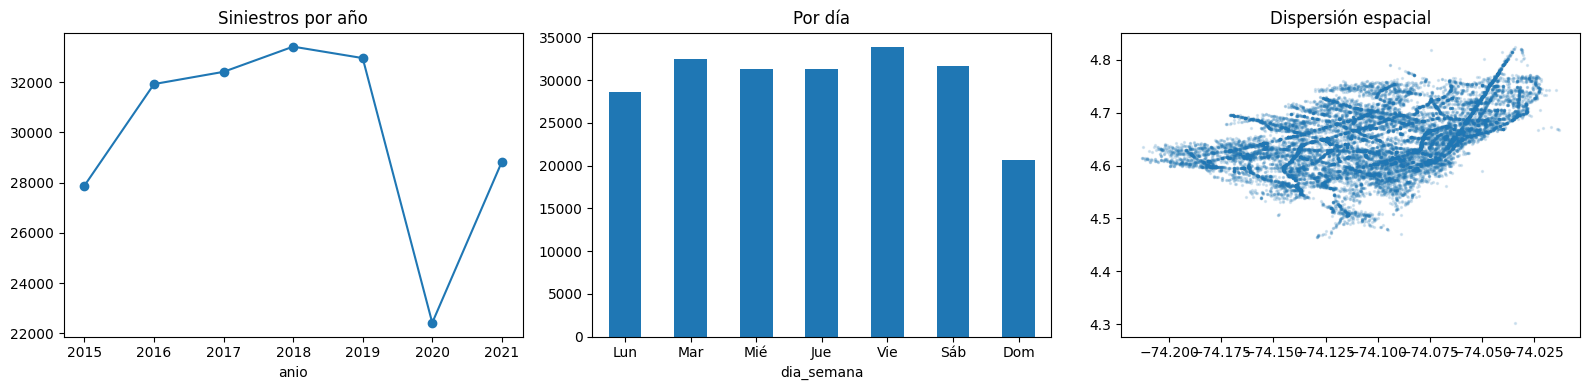

Coordenadas válidas: 100.00%

Top localidades (tasa fatal %):
                siniestros  tasa_fatal
LOCALIDAD_norm                        
KENNEDY              25116        1.89
ENGATIVA             22085        1.40
USAQUEN              20109        0.86
SUBA                 20021        1.39
FONTIBON             17279        1.42
PUENTE ARANDA        14957        1.61
CHAPINERO            12153        0.80
TEUSAQUILLO          10657        1.10
BARRIOS UNIDOS       10593        1.03
BOSA                  9922        2.13


In [6]:
# Patrones temporales y espaciales
fig, ax = plt.subplots(1, 3, figsize=(16,4))
df.groupby("anio").size().plot(ax=ax[0], marker="o"); ax[0].set_title("Siniestros por año")
dias=["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]
df.groupby("dia_semana").size().reindex(range(7)).plot(kind="bar", ax=ax[1]); ax[1].set_xticklabels(dias,rotation=0); ax[1].set_title("Por día")
def _bbox(lat,lon): return lat.between(4.0,4.9)&lon.between(-74.30,-73.95)
df["coord_valida"]=_bbox(df["lat"],df["lon"])
m=df[df["coord_valida"]].sample(min(20000,int(df["coord_valida"].sum())),random_state=SEED)
ax[2].scatter(m["lon"],m["lat"],s=2,alpha=0.15); ax[2].set_title("Dispersión espacial")
plt.tight_layout(); plt.show()
print("Coordenadas válidas:", f"{df['coord_valida'].mean()*100:.2f}%")
print("\nTop localidades (tasa fatal %):")
print(df.groupby("LOCALIDAD_norm").agg(siniestros=("OBJECTID","size"),
      tasa_fatal=("es_grave", lambda s: round(s.mean()*100,2))).sort_values("siniestros",ascending=False).head(10))

### Métrica y validación (fijadas ANTES de modelar)
**Métrica:** la clase fatal es ~1,6 %, así que la exactitud queda descartada. Se usa **F1 macro** (selección), **recall de "Con muertos"** (negocio) y **PR-AUC** por clase; se reporta matriz de confusión.

**Validación:** **partición temporal** (no aleatoria) - train 2015–2018, validación 2019, test 2021, **2020 excluido** (COVID). Todo ajuste se aprende solo en *train*.

In [7]:
def particion_temporal(d, excluir=(2020,)):
    anios = sorted(int(a) for a in d["anio"].dropna().unique() if int(a) not in excluir)
    test, val = anios[-1:], anios[-2:-1]
    train = [a for a in anios if a not in test+val]
    return {"train":train,"val":val,"test":test,"excluidos":list(excluir)}
part = particion_temporal(df); print("Partición:", part)
for n,a in [("train",part["train"]),("val",part["val"]),("test",part["test"])]:
    sub=df[df["anio"].isin(a)]; print(f"  {n:5s} {a}: {len(sub):,} | %fatal {sub['es_grave'].mean()*100:.2f}")

Partición: {'train': [2015, 2016, 2017, 2018], 'val': [2019], 'test': [2021], 'excluidos': [2020]}
  train [2015, 2016, 2017, 2018]: 125,646 | %fatal 1.65
  val   [2019]: 32,962 | %fatal 1.50
  test  [2021]: 28,829 | %fatal 1.59


---
## 2. Enriquecimiento con tablas relacionales

Unimos por **`CODIGO_ACCIDENTE`** las tablas del Excel *Consolidados* (SINIESTROS, ACTOR_VIAL, VEHICULOS, HIPOTESIS, DICCIONARIO). **Recuperamos la hora del día** (en `SINIESTROS.HORA`). **`ESTADO`** (ileso/herido/muerto) se **excluye** por fuga de datos.

> **Nota de reproducibilidad:** el portal a veces rechaza conexiones desde IP de centros de datos (p. ej. ciertas sesiones de Colab) y la descarga del Excel cae en *timeout*; en un entorno local funciona. Hay subida manual de respaldo; el archivo queda en caché.

In [8]:
XLSX_URL = ("https://datosabiertos.bogota.gov.co/dataset/0b070626-fe5a-42dc-ae99-92601da166d9/"
            "resource/9e3add8e-3f46-42ce-9c0f-419964f6f598/download/siniestros_viales_consolidados_bogota_dc.xlsx")
XLSX_PATH = Path("data/raw/siniestros_consolidados.xlsx")

def descargar_xlsx(url=XLSX_URL, path=XLSX_PATH, intentos=2):
    if path.exists(): print(f"[cache] {path}"); return path
    hdr={"User-Agent":"Mozilla/5.0 (TFM)","Accept":"*/*"}
    for i in range(1,intentos+1):
        try:
            r=requests.get(url,headers=hdr,timeout=(20,300),allow_redirects=True); r.raise_for_status()
            path.write_bytes(r.content); print(f"[guardado] {path} ({path.stat().st_size/1e6:.1f} MB)"); return path
        except Exception as e: print(f"  falló intento {i}: {type(e).__name__}")
    print("Descarga automática no disponible. Sube el .xlsx (bájalo del navegador):")
    from google.colab import files
    up=files.upload(); path.write_bytes(up[next(iter(up))]); return path

ruta = descargar_xlsx()
hojas = pd.read_excel(ruta, sheet_name=None)
print("Hojas:", list(hojas.keys()))

[guardado] data/raw/siniestros_consolidados.xlsx (49.2 MB)
Hojas: ['SINIESTROS', 'ACTOR_VIAL', 'VEHICULOS', 'HIPOTESIS', 'DICCIONARIO']


In [9]:
# Diccionario de decodificación
dicc = hojas["DICCIONARIO"].copy()
dicc.columns=[str(c).strip().upper() for c in dicc.columns]
for c in ["HOJA","CAMPO"]: dicc[c]=dicc[c].astype(str).str.strip().str.upper()
dicc["CODIGO"]=pd.to_numeric(dicc["CODIGO"],errors="coerce")
DECODE={}
for (h,c),g in dicc.dropna(subset=["CODIGO"]).groupby(["HOJA","CAMPO"]):
    DECODE[(h,c)]=dict(zip(g["CODIGO"].astype(int), g["DESCRIPCION"].astype(str).str.strip()))
def decodificar(serie,hoja,campo):
    m=DECODE.get((hoja.upper(),campo.upper()))
    if not m: print(f"  [aviso] sin diccionario para {hoja}.{campo}"); return serie
    return pd.to_numeric(serie,errors="coerce").map(m)
print("Pares decodificables:", len(DECODE))

Pares decodificables: 10


In [10]:
# SINIESTROS -> hora recuperada, franja y diseño del lugar
sin = hojas["SINIESTROS"].copy()
sin["CODIGO_ACCIDENTE"]=pd.to_numeric(sin["CODIGO_ACCIDENTE"],errors="coerce").astype("Int64")
sin["hora"]=pd.to_datetime(sin["HORA"].astype(str).str.strip(), format="%H:%M:%S", errors="coerce").dt.hour
def franja(h):
    if pd.isna(h): return np.nan
    h=int(h); return "Madrugada" if h<6 else "Mañana" if h<12 else "Tarde" if h<18 else "Noche"
sin["franja_horaria"]=sin["hora"].map(franja)
sin["diseno_lugar"]=decodificar(sin["DISENO_LUGAR"],"SINIESTROS","DISENO_LUGAR").astype("string")
sin_feats=sin[["CODIGO_ACCIDENTE","hora","franja_horaria","diseno_lugar"]].drop_duplicates("CODIGO_ACCIDENTE")
print("Hora recuperada -> % no nula:", round(sin_feats["hora"].notna().mean()*100,1))

Hora recuperada -> % no nula: 100.0


In [11]:
# VEHICULOS -> agregación por siniestro
veh=hojas["VEHICULOS"].copy()
veh["CODIGO_ACCIDENTE"]=pd.to_numeric(veh["CODIGO_ACCIDENTE"],errors="coerce").astype("Int64")
veh["cd"]=decodificar(veh["CLASE"],"VEHICULOS","CLASE").astype("string").str.upper()
for kw,col in [("MOTO","es_moto"),("BICI","es_bici"),("BUS","es_bus"),("CAMION","es_camion")]:
    veh[col]=veh["cd"].str.contains(kw,na=False)
veh_agg=veh.groupby("CODIGO_ACCIDENTE").agg(n_vehiculos=("VEHICULO","count"),
    involucra_moto=("es_moto","max"),involucra_bici=("es_bici","max"),
    involucra_bus=("es_bus","max"),involucra_camion=("es_camion","max")).reset_index()

# ACTOR_VIAL -> agregación SIN ESTADO (fuga)
act=hojas["ACTOR_VIAL"].copy()
act["CODIGO_ACCIDENTE"]=pd.to_numeric(act["CODIGO_ACCIDENTE"],errors="coerce").astype("Int64")
act["CONDICION"]=act["CONDICION"].astype("string").str.strip().str.upper()
act["EDAD"]=pd.to_numeric(act["EDAD"],errors="coerce")
for kw,col in [("PEATON","es_peaton"),("MOTO","es_motoc"),("CICLISTA","es_cicl"),("PASAJERO","es_pas")]:
    act[col]=act["CONDICION"].str.contains(kw,na=False)
act_agg=act.groupby("CODIGO_ACCIDENTE").agg(n_actores=("CODIGO_ACCIDENTADO","count"),
    involucra_peaton=("es_peaton","max"),involucra_motociclista=("es_motoc","max"),
    involucra_ciclista=("es_cicl","max"),involucra_pasajero=("es_pas","max"),
    edad_min=("EDAD","min"),edad_prom=("EDAD","mean")).reset_index()

# HIPOTESIS -> causa principal (moda)
hip=hojas["HIPOTESIS"].copy()
hip["CODIGO_ACCIDENTE"]=pd.to_numeric(hip["CODIGO_ACCIDENTE"],errors="coerce").astype("Int64")
hip["cd"]=decodificar(hip["CODIGO_CAUSA"],"HIPOTESIS","CODIGO_CAUSA").astype("string").str.strip()
def _moda(s):
    s=s.dropna(); return s.mode().iloc[0] if not s.mode().empty else np.nan
hip_agg=hip.groupby("CODIGO_ACCIDENTE").agg(n_hipotesis=("CODIGO_CAUSA","count"),
    causa_principal=("cd",_moda)).reset_index()
print("Agregados listos:", veh_agg.shape, act_agg.shape, hip_agg.shape)

Agregados listos: (196004, 6) (196004, 8) (195735, 3)


In [12]:
# UNIÓN sobre la base (left join), cobertura y relleno de banderas
codigos = df["CODIGO_ACCIDENTE"]
df = (df.merge(sin_feats,on="CODIGO_ACCIDENTE",how="left")
        .merge(veh_agg,on="CODIGO_ACCIDENTE",how="left")
        .merge(act_agg,on="CODIGO_ACCIDENTE",how="left")
        .merge(hip_agg,on="CODIGO_ACCIDENTE",how="left"))
print("Cobertura del enriquecimiento:")
for n,a in [("SINIESTROS/hora",sin_feats),("VEHICULOS",veh_agg),("ACTOR_VIAL",act_agg),("HIPOTESIS",hip_agg)]:
    print(f"  {n:16s}: {codigos.isin(a['CODIGO_ACCIDENTE']).mean()*100:5.1f}%")
flags=[c for c in df.columns if c.startswith("involucra_")]
df[flags]=df[flags].fillna(False).astype(bool)
print("Enriquecido:", df.shape)

Cobertura del enriquecimiento:
  SINIESTROS/hora :  86.3%
  VEHICULOS       :  86.2%
  ACTOR_VIAL      :  86.2%
  HIPOTESIS       :  86.1%
Enriquecido: (209861, 48)


---
## 3. Features adicionales

Temporales (fin de semana, festivo, cíclicas), espaciales (**malla H3**), interacciones y **agrupamiento temático de la causa**. Solo features que **no usan el target**: la tasa de letalidad por zona se calculará dentro de la validación cruzada (solo en *train*) en el modelado.

In [13]:
!pip install -q h3 holidays
import h3, holidays as hol
_to_cell = getattr(h3, "latlng_to_cell", None) or h3.geo_to_h3
festivos_co = hol.country_holidays("CO")

# Temporales
df["es_fin_semana"]=df["dia_semana"].isin([5,6])
df["es_festivo"]=df["fecha_hora"].dt.date.map(lambda d:(d in festivos_co) if pd.notna(d) else False)
df["es_finde_o_festivo"]=df["es_fin_semana"]|df["es_festivo"]
df["hora_sin"]=np.sin(2*np.pi*df["hora"]/24); df["hora_cos"]=np.cos(2*np.pi*df["hora"]/24)
df["mes_sin"]=np.sin(2*np.pi*df["mes"]/12);   df["mes_cos"]=np.cos(2*np.pi*df["mes"]/12)

# Espaciales H3 (res7 zona, res8 barrio)
def asignar_h3(d,res):
    out=np.full(len(d),None,dtype=object)
    m=(d["lat"].notna()&d["lon"].notna()).to_numpy()
    la=d["lat"].to_numpy(); lo=d["lon"].to_numpy(); idx=np.where(m)[0]
    out[idx]=[_to_cell(la[i],lo[i],res) for i in idx]; return out
df["h3_res7"]=asignar_h3(df,7); df["h3_res8"]=asignar_h3(df,8)

# Interacciones
fr_noche=df["franja_horaria"].isin(["Noche","Madrugada"])
dis=df["diseno_lugar"].astype("string")
df["moto_noche"]=df["involucra_moto"].fillna(False)&fr_noche
df["peaton_interseccion"]=df["involucra_peaton"].fillna(False)&dis.str.contains("INTERSEC",case=False,na=False)
df["bici_finde"]=df["involucra_bici"].fillna(False)&df["es_fin_semana"]
print("Festivos:",int(df["es_festivo"].sum()),"| celdas res8:",df["h3_res8"].nunique())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.6 MB/s eta 0:00:00
Festivos: 5645 | celdas res8: 605


In [14]:
# Agrupamiento temático de la causa (limpio) + indicador de datos faltantes
def _nc(x):
    if pd.isna(x): return ""
    x=unicodedata.normalize("NFKD",str(x).lower()); return "".join(c for c in x if not unicodedata.combining(c))
def agrupar_causa(c):
    if pd.isna(c): return "Sin dato"
    t=_nc(c)
    if any(k in t for k in ["embriag","alcohol","drog"]): return "Embriaguez/sustancias"
    if "exceso" in t or "velocidad" in t:                 return "Exceso de velocidad"
    if "distancia" in t:                                  return "No mantener distancia"
    if "adelantar" in t:                                  return "Adelantamiento indebido"
    if any(k in t for k in ["semaforo","senal","prelacion","rojo","pare"]): return "Desobedecer señales/prelación"
    if "peaton" in t or "cruzar" in t:                    return "Conducta del peatón"
    if any(k in t for k in ["reverso","girar","arrancar","marcha","transitar entre","zigzag","invadiendo","carril","brusc"]):
        return "Maniobra/giro imprudente"
    return "Otra / no especificada"
df["grupo_causa"]=df["causa_principal"].map(agrupar_causa)
df["sin_dato_relacional"]=df["n_actores"].isna()
print(df["grupo_causa"].value_counts(dropna=False))
print("\nSin dato relacional:", f"{df['sin_dato_relacional'].mean()*100:.1f}%")

grupo_causa
No mantener distancia            43206
Adelantamiento indebido          37289
Otra / no especificada           35760
Desobedecer señales/prelación    30865
Sin dato                         29231
Maniobra/giro imprudente         17532
Conducta del peatón              10258
Embriaguez/sustancias             4039
Exceso de velocidad               1681
Name: count, dtype: int64

Sin dato relacional: 13.8%


### Persistencia del dataset modelable
Guardamos el dataset final. En la siguiente fase (modelado) se añadirá a este mismo notebook la selección de variables, la codificación, el entrenamiento y la interpretabilidad.

In [15]:
COLS = ["OBJECTID","CODIGO_ACCIDENTE","gravedad","es_grave","CLASE_ACC_norm","LOCALIDAD_norm",
        "fecha_hora","anio","mes","dia_semana","hora","franja_horaria","es_fin_semana",
        "es_festivo","es_finde_o_festivo","hora_sin","hora_cos","mes_sin","mes_cos",
        "lat","lon","coord_valida","h3_res7","h3_res8","diseno_lugar",
        "n_vehiculos","involucra_moto","involucra_bici","involucra_bus","involucra_camion",
        "n_actores","involucra_peaton","involucra_motociclista","involucra_ciclista","involucra_pasajero",
        "edad_min","edad_prom","n_hipotesis","causa_principal","grupo_causa",
        "moto_noche","peaton_interseccion","bici_finde","sin_dato_relacional"]
final = df[[c for c in COLS if c in df.columns]].copy()
dest = Path("data/processed/siniestros_modelable.parquet")
try: final.to_parquet(dest,index=False); print(f"Guardado: {dest} | {final.shape}")
except Exception as e:
    dest=dest.with_suffix(".csv"); final.to_csv(dest,index=False); print(f"CSV: {dest} | {final.shape}")

Guardado: data/processed/siniestros_modelable.parquet | (209861, 44)


### Resumen
Pipeline reproducible de extremo a extremo: carga (209.861 siniestros, 2015–2021) → EDA y validación temporal → enriquecimiento relacional (recuperando la hora del día, sin fuga de `ESTADO`) → features temporales/espaciales/interacciones y causa agrupada. **Siguiente:** modelado (baseline → modelos, métricas y SHAP) y mapa de riesgo, que se añadirán a este mismo notebook.

---
## 4. Dataset modelable

Definimos `X`/`y`. **Excluimos**: identificadores (`OBJECTID`, `CODIGO_ACCIDENTE`); el target y sus derivados (`gravedad` es `y`; `es_grave` deriva de él → fuga); `anio` (variable de partición temporal); `fecha_hora` y `causa_principal` cruda (usamos `grupo_causa`).

**Codificación:** las categóricas se dejan como tipo `category` y se usa el **soporte nativo de LightGBM** (splits óptimos sin one-hot ni target encoding manual, evitando explotar las celdas H3 y sin fuga). Los `NaN` se conservan (LightGBM los maneja). **Target:** `gravedad` en 3 clases ordinales.

In [16]:
df_mod = pd.read_parquet("data/processed/siniestros_modelable.parquet")

ORDEN_G = {"Solo daños": 0, "Con heridos": 1, "Con muertos": 2}
y = df_mod["gravedad"].map(ORDEN_G).astype("int8")

cat_cols = ["CLASE_ACC_norm", "LOCALIDAD_norm", "franja_horaria", "diseno_lugar",
            "h3_res7", "h3_res8", "grupo_causa"]
num_cols = ["mes", "dia_semana", "hora", "hora_sin", "hora_cos", "mes_sin", "mes_cos",
            "lat", "lon", "n_vehiculos", "n_actores", "edad_min", "edad_prom", "n_hipotesis"]
bool_cols = ["es_fin_semana", "es_festivo", "es_finde_o_festivo",
             "involucra_moto", "involucra_bici", "involucra_bus", "involucra_camion",
             "involucra_peaton", "involucra_motociclista", "involucra_ciclista", "involucra_pasajero",
             "moto_noche", "peaton_interseccion", "bici_finde", "sin_dato_relacional"]

feature_cols = [c for c in cat_cols + num_cols + bool_cols if c in df_mod.columns]
X = df_mod[feature_cols].copy()
for c in cat_cols:
    if c in X: X[c] = X[c].astype("category")
for c in bool_cols:
    if c in X: X[c] = X[c].astype("bool")
print("X:", X.shape, "| features:", len(feature_cols))
print("Clases del target:", {k: int(v) for k, v in pd.Series(y).value_counts().sort_index().items()})

X: (209861, 36) | features: 36
Clases del target: {0: 134812, 1: 71656, 2: 3393}


### Validación: por qué el split es 2015–2019
Antes de partir, verificamos la **cobertura del enriquecimiento por año**. El consolidado relacional cubre 2015–2020; **2021 llega con el 100 % de las variables de enriquecimiento vacías**, y 2020 está distorsionado por la COVID. Por eso la partición temporal honesta usa solo el periodo con datos completos y sin distorsión: **train 2015–2017, val 2018, test 2019**.

In [17]:
cob = (df_mod.groupby("anio")
       .agg(n=("CODIGO_ACCIDENTE", "size"),
            sin_dato_rel_pct=("sin_dato_relacional", lambda s: round(s.mean()*100, 1)),
            hora_nula_pct=("hora", lambda s: round(s.isna().mean()*100, 1))))
print(cob)

          n  sin_dato_rel_pct  hora_nula_pct
anio                                        
2015  27885               0.0            0.0
2016  31928               0.0            0.0
2017  32415               0.1            0.0
2018  33418               0.2            0.0
2019  32962               0.0            0.0
2020  22424               0.1            0.1
2021  28829             100.0          100.0


> **Hallazgos (validación):** la cobertura por año muestra que 2015–2020 están ~100 % enriquecidos y **2021 al 0 %** (el consolidado va con rezago). Evaluar en 2021 mediría "predecir sin features", no la capacidad real del modelo. Se fija el split en el periodo completo y sin COVID. *Implicación de producción: para puntuar el año más reciente se requiere la fuente relacional al día (o un modelo alterno solo-base).*

In [18]:
# Split temporal: periodo con enriquecimiento completo (2015-2019), sin COVID
anio = df_mod["anio"]
masks = {"train": anio.isin([2015, 2016, 2017]),
         "val":   anio.isin([2018]),
         "test":  anio.isin([2019])}
X_train, y_train = X[masks["train"].to_numpy()], y[masks["train"].to_numpy()]
X_val,   y_val   = X[masks["val"].to_numpy()],   y[masks["val"].to_numpy()]
X_test,  y_test  = X[masks["test"].to_numpy()],  y[masks["test"].to_numpy()]
for nm, (xx, yy) in [("train",(X_train,y_train)),("val",(X_val,y_val)),("test",(X_test,y_test))]:
    dist = (pd.Series(yy).value_counts(normalize=True).sort_index()*100).round(2).to_dict()
    print(f"{nm:5s}: X{xx.shape} | dist% {dist}")

train: X(92228, 36) | dist% {0: 66.71, 1: 31.59, 2: 1.7}
val  : X(33418, 36) | dist% {0: 64.31, 1: 34.2, 2: 1.5}
test : X(32962, 36) | dist% {0: 63.15, 1: 35.35, 2: 1.5}


---
## 5. Baseline y modelos

Métricas (clase fatal ~1,6 %): **F1 macro**, **recall de "Con muertos"** y **PR-AUC**; nada de exactitud. Comparamos un baseline trivial con **LightGBM** (categóricas y `NaN` nativos, no lineal, `class_weight="balanced"` para el desbalance). `val` para *early stopping*; `test` (2019) reservado para la cifra final.

In [19]:
!pip install -q lightgbm
import lightgbm as lgb
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, recall_score, confusion_matrix, average_precision_score, precision_score
from sklearn.preprocessing import label_binarize

CLASES = ("Solo daños", "Con heridos", "Con muertos")
def evaluar(nombre, y_true, y_pred, proba=None):
    print(f"=== {nombre} ===")
    print("F1 macro:", round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4))
    rec = recall_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    print("Recall por clase:", {CLASES[i]: round(float(rec[i]), 3) for i in range(3)})
    print("  -> Recall 'Con muertos':", round(float(rec[2]), 3))
    if proba is not None:
        yb = label_binarize(y_true, classes=[0,1,2])
        ap = [round(float(average_precision_score(yb[:, i], proba[:, i])), 3) for i in range(3)]
        print("PR-AUC por clase:", {CLASES[i]: ap[i] for i in range(3)})
    print("Matriz de confusión:\n", confusion_matrix(y_true, y_pred, labels=[0,1,2]))
    print()

In [20]:
# Baseline: clase mayoritaria
base = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
evaluar("Baseline (clase mayoritaria) — val", y_val, base.predict(X_val))

=== Baseline (clase mayoritaria) — val ===
F1 macro: 0.2609
Recall por clase: {'Solo daños': 1.0, 'Con heridos': 0.0, 'Con muertos': 0.0}
  -> Recall 'Con muertos': 0.0
Matriz de confusión:
 [[21490     0     0]
 [11428     0     0]
 [  500     0     0]]



### Comparación de modelos
Comparamos, en el mismo split y con la misma métrica, cuatro alternativas: **Random Forest** (ensemble clásico, con categóricas codificadas por frecuencia e imputación), **XGBoost** y **CatBoost** (boosting con categóricas nativas) y **LightGBM**. La elección final se basa en F1 macro y en el desempeño en la clase fatal (recall y PR-AUC).

In [21]:
!pip install -q xgboost catboost
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

def metricas(y_true, y_pred, proba):
    yb = label_binarize(y_true, classes=[0, 1, 2])
    return {"F1_macro": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
            "recall_fatal": round(float(recall_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)[2]), 3),
            "PR_AUC_fatal": round(float(average_precision_score(yb[:, 2], proba[:, 2])), 3)}

comp = {}

mL = lgb.LGBMClassifier(objective="multiclass", n_estimators=800, learning_rate=0.03, num_leaves=31,
        min_child_samples=300, reg_lambda=5, reg_alpha=1, subsample=0.8, colsample_bytree=0.7,
        class_weight="balanced", random_state=SEED, n_jobs=-1, verbose=-1)
mL.fit(X_train, y_train, categorical_feature=cat_cols)
comp["LightGBM"] = metricas(y_val, mL.predict(X_val), mL.predict_proba(X_val))

def cat_fill(Z):
    Z = Z.copy()
    for c in cat_cols: Z[c] = Z[c].astype("string").fillna("SIN_DATO")
    return Z
mC = CatBoostClassifier(iterations=800, learning_rate=0.03, depth=6, l2_leaf_reg=5,
        loss_function="MultiClass", auto_class_weights="Balanced", random_state=SEED, verbose=0)
mC.fit(cat_fill(X_train), y_train, cat_features=cat_cols)
comp["CatBoost"] = metricas(y_val, mC.predict(cat_fill(X_val)).ravel().astype(int), mC.predict_proba(cat_fill(X_val)))

sw = compute_sample_weight("balanced", y_train)
mX = xgb.XGBClassifier(n_estimators=800, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.7,
        tree_method="hist", enable_categorical=True, objective="multi:softprob", num_class=3,
        random_state=SEED, verbosity=0)
mX.fit(X_train, y_train, sample_weight=sw)
comp["XGBoost"] = metricas(y_val, mX.predict(X_val), mX.predict_proba(X_val))

def encode(Xfit, Z):
    out = Z.copy()
    for c in cat_cols:
        freq = Xfit[c].astype("string").value_counts(normalize=True)
        out[c] = Z[c].astype("string").map(freq).fillna(0)
    for c in num_cols:
        out[c] = Z[c].fillna(Xfit[c].median())
    return out.astype(float)
mR = RandomForestClassifier(n_estimators=400, class_weight="balanced", n_jobs=-1, random_state=SEED)
mR.fit(encode(X_train, X_train), y_train)
comp["RandomForest"] = metricas(y_val, mR.predict(encode(X_train, X_val)), mR.predict_proba(encode(X_train, X_val)))

tabla = pd.DataFrame(comp).T.sort_values("F1_macro", ascending=False)
print(tabla.to_string())
print("\nMejor por F1 macro:", tabla.index[0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
              F1_macro  recall_fatal  PR_AUC_fatal
XGBoost         0.6524         0.204         0.098
LightGBM        0.6514         0.202         0.098
CatBoost        0.6301         0.696         0.197
RandomForest    0.6272         0.032         0.177

Mejor por F1 macro: XGBoost


### Modelo final seleccionado: CatBoost
Las cuatro alternativas quedan parejas en F1 macro (~0,63–0,65), pero el objetivo del proyecto es **detectar la clase fatal**. Ahí **CatBoost domina**: recall fatal ~0,70 (frente a ~0,20 de XGBoost/LightGBM) y **PR-AUC fatal ~0,20, el doble** que el resto. Diseñado para categóricas de alta cardinalidad (zona H3, localidad, causa), discrimina la fatalidad mucho mejor, y esa probabilidad alimenta el mapa de riesgo. Se selecciona **CatBoost**, priorizando la métrica de negocio sobre una diferencia marginal de F1 macro. Se reserva `test` (2019) para la cifra imparcial.

In [22]:
# Modelo final: CatBoost (categóricas nativas de alta cardinalidad, reequilibrio de clases)
from catboost import CatBoostClassifier, Pool

def cat_fill(Z):
    Z = Z.copy()
    for c in cat_cols: Z[c] = Z[c].astype("string").fillna("SIN_DATO")
    return Z
Xc_train, Xc_val, Xc_test = cat_fill(X_train), cat_fill(X_val), cat_fill(X_test)

modelo = CatBoostClassifier(iterations=1500, learning_rate=0.03, depth=6, l2_leaf_reg=5,
        loss_function="MultiClass", auto_class_weights="Balanced", random_state=SEED, verbose=0)
modelo.fit(Xc_train, y_train, cat_features=cat_cols,
           eval_set=(Xc_val, y_val), early_stopping_rounds=80, verbose=0)

pred = lambda Z: modelo.predict(Z).ravel().astype(int)
evaluar("Modelo final (CatBoost) — val 2018",  y_val,  pred(Xc_val),  modelo.predict_proba(Xc_val))
evaluar("Modelo final (CatBoost) — TEST 2019", y_test, pred(Xc_test), modelo.predict_proba(Xc_test))
Xtr_s = Xc_train.sample(min(30000, len(Xc_train)), random_state=SEED)
print("F1 train/val/test:",
      round(f1_score(y_train.loc[Xtr_s.index], pred(Xtr_s), average="macro"), 3),
      round(f1_score(y_val,  pred(Xc_val),  average="macro"), 3),
      round(f1_score(y_test, pred(Xc_test), average="macro"), 3))

=== Modelo final (CatBoost) — val 2018 ===
F1 macro: 0.6378
Recall por clase: {'Solo daños': 0.908, 'Con heridos': 0.751, 'Con muertos': 0.65}
  -> Recall 'Con muertos': 0.65
PR-AUC por clase: {'Solo daños': 0.986, 'Con heridos': 0.91, 'Con muertos': 0.203}
Matriz de confusión:
 [[19505  1687   298]
 [  545  8580  2303]
 [    4   171   325]]

=== Modelo final (CatBoost) — TEST 2019 ===
F1 macro: 0.635
Recall por clase: {'Solo daños': 0.899, 'Con heridos': 0.767, 'Con muertos': 0.609}
  -> Recall 'Con muertos': 0.609
PR-AUC por clase: {'Solo daños': 0.986, 'Con heridos': 0.911, 'Con muertos': 0.205}
Matriz de confusión:
 [[18706  1745   366]
 [  449  8940  2263]
 [    6   187   300]]

F1 train/val/test: 0.685 0.638 0.635


> **Hallazgos (modelado):** se compararon cuatro modelos en el mismo split. Aunque XGBoost y LightGBM lideran por poco en F1 macro (~0,65 vs 0,64 de CatBoost), **se eligió CatBoost por su desempeño en la clase fatal**: recall **0,61 en test** (frente a ~0,20) y PR-AUC fatal **0,205** (el doble), alineado con Visión Cero. Además **generaliza mejor** —train/val/test 0,69 / 0,64 / 0,64, sin la gran brecha de sobreajuste de LightGBM—, y **val≈test** confirma robustez.

### Punto de operación para la clase fatal
El `argmax` favorece a las mayoritarias. Tratamos la detección de fatales como un **flag por probabilidad**: tomamos `P(Con muertos)` y elegimos sobre `val` el umbral para un recall objetivo, asumiendo la caída de precisión. Es una **palanca de política**, y esta probabilidad alimenta el mapa de riesgo.

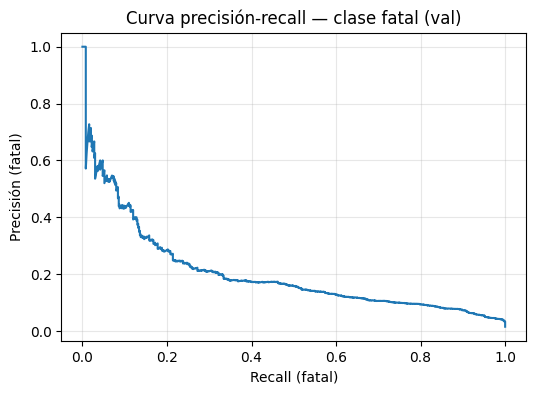

Recall objetivo -> umbral | precisión | nº marcados
  30% -> 0.7019 | prec 0.211 | 712
  40% -> 0.6359 | prec 0.173 | 1155
  50% -> 0.5883 | prec 0.159 | 1573
  60% -> 0.5167 | prec 0.128 | 2336
  70% -> 0.4447 | prec 0.106 | 3310

Punto de operación: umbral=0.5883


In [23]:
from sklearn.metrics import precision_recall_curve
proba_val = modelo.predict_proba(Xc_val)
p_fatal = proba_val[:, 2]
y_fatal = (y_val.to_numpy() == 2).astype(int)
prec, rec, thr = precision_recall_curve(y_fatal, p_fatal)

plt.figure(figsize=(6, 4)); plt.plot(rec, prec)
plt.xlabel("Recall (fatal)"); plt.ylabel("Precisión (fatal)")
plt.title("Curva precisión-recall — clase fatal (val)"); plt.grid(alpha=.3); plt.show()

print("Recall objetivo -> umbral | precisión | nº marcados")
for obj in [0.3, 0.4, 0.5, 0.6, 0.7]:
    m = rec[:-1] >= obj
    if m.any():
        u = float(thr[m][-1]); pf = (p_fatal >= u).astype(int)
        print(f"  {obj:.0%} -> {u:.4f} | prec {precision_score(y_fatal, pf, zero_division=0):.3f} | {int(pf.sum())}")
OBJETIVO_RECALL = 0.5
m = rec[:-1] >= OBJETIVO_RECALL
UMBRAL_FATAL = float(thr[m][-1]) if m.any() else 0.5
print(f"\nPunto de operación: umbral={UMBRAL_FATAL:.4f}")

> **Hallazgos (operación):** el intercambio precisión-recall de la clase fatal muestra un núcleo de alto riesgo bien identificado (recall ~5–7 % con precisión ~0,5) y un fuerte coste de precisión al ampliar el recall (recall 0,50 ⇒ precisión ~0,08). Parte de la fatalidad es **circunstancial y no capturada por las variables disponibles** — una limitación de la fuente. El mapa usa la **probabilidad continua**, no un único umbral.

---
## 6. Interpretabilidad (SHAP)
SHAP descompone cada predicción en la contribución de cada variable. Vemos la **importancia global** y los **drivers de la clase fatal**.

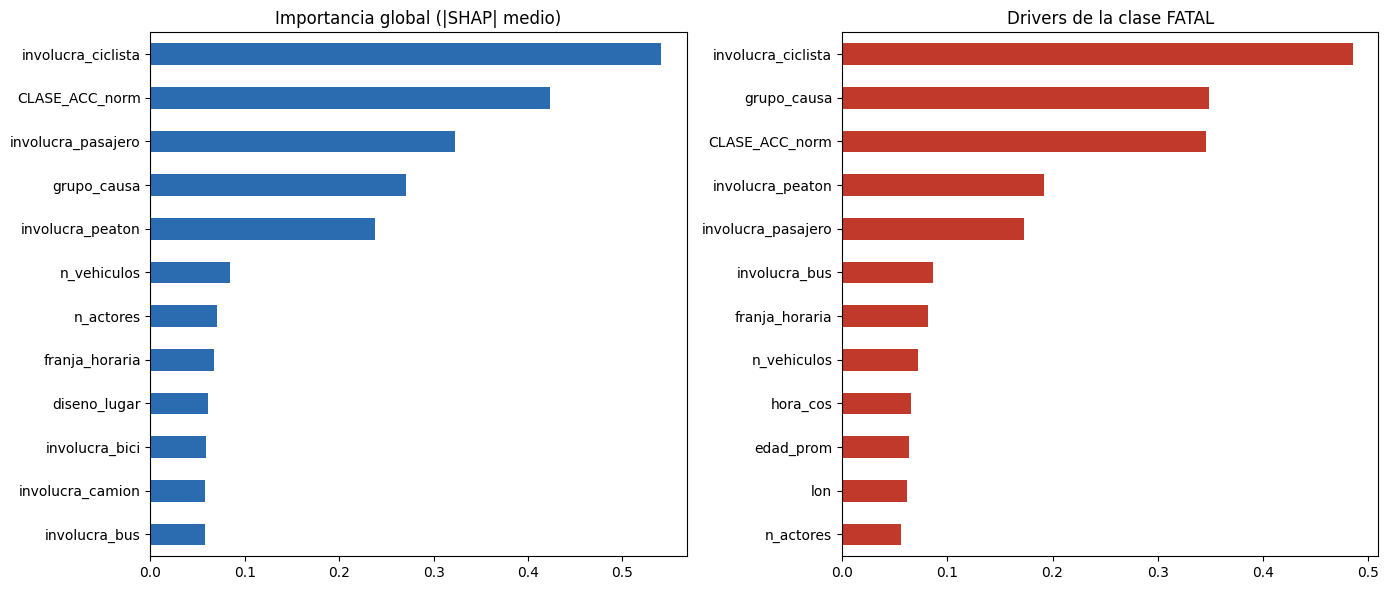

Top drivers fatal:
 involucra_ciclista    0.485
grupo_causa           0.348
CLASE_ACC_norm        0.345
involucra_peaton      0.192
involucra_pasajero    0.173
involucra_bus         0.086
franja_horaria        0.082
n_vehiculos           0.072
dtype: float64


In [24]:
# SHAP con CatBoost (método nativo: get_feature_importance type='ShapValues')
from catboost import Pool
Xs = Xc_train.sample(min(4000, len(Xc_train)), random_state=SEED)
sv = np.array(modelo.get_feature_importance(Pool(Xs, cat_features=cat_cols), type="ShapValues"))  # (n, clases, feat+1)

imp_global = pd.Series(np.abs(sv[:, :, :-1]).mean(axis=(0, 1)), index=Xs.columns).sort_values(ascending=False)
imp_fatal  = pd.Series(np.abs(sv[:, 2, :-1]).mean(axis=0),       index=Xs.columns).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
imp_global.head(12)[::-1].plot(kind="barh", ax=ax[0], color="#2b6cb0"); ax[0].set_title("Importancia global (|SHAP| medio)")
imp_fatal.head(12)[::-1].plot(kind="barh", ax=ax[1], color="#c0392b"); ax[1].set_title("Drivers de la clase FATAL")
plt.tight_layout(); plt.show()
print("Top drivers fatal:\n", imp_fatal.head(8).round(3))

> **Lectura de negocio (SHAP):** con CatBoost, los determinantes de la gravedad y de la fatalidad apuntan a **quién y cómo**: la presencia de **ciclista** encabeza con claridad, seguida de la **causa**, el **tipo de siniestro** (`CLASE_ACC`), y la presencia de **peatón** y **pasajero**; detrás, **vehículos pesados** (bus) y el **momento** del día. CatBoost se apoya menos en memorizar la zona y más en la **vulnerabilidad del usuario** y la **naturaleza del siniestro**: un relato robusto y accionable —proteger a ciclistas y peatones y atacar causas concretas salva más vidas—. El *dónde* lo aporta el mapa de riesgo.

---
## 7. Mapa de riesgo (productivización)
Producto operativo: mapa interactivo de la **tasa de fatalidad observada por zona** (malla H3 res7), usando `es_grave` —disponible para todos los años—, por tanto **robusto e independiente del drift**. El modelo + SHAP explican el *porqué*; el mapa muestra el *dónde*.

In [25]:
!pip install -q folium branca
import folium, branca, h3
_boundary = getattr(h3, "cell_to_boundary", None) or h3.h3_to_geo_boundary

zona = (df_mod.dropna(subset=["h3_res7"]).groupby("h3_res7")
        .agg(n=("es_grave","size"), n_fatal=("es_grave","sum"),
             localidad=("LOCALIDAD_norm", lambda s: s.mode().iloc[0] if not s.mode().empty else "—"))
        .reset_index())
zona["tasa_fatal"] = (zona["n_fatal"]/zona["n"]*100).round(2)
zona = zona[zona["n"] >= 50].copy()
print(f"Zonas en el mapa: {len(zona)} | tasa fatal media: {zona['tasa_fatal'].mean():.2f}%")

vmax = float(zona["tasa_fatal"].quantile(0.95))
cmap = branca.colormap.LinearColormap(["#2c7fb8","#ffffb2","#f03b20"], vmin=0, vmax=vmax, caption="Tasa de fatalidad (%)")
mapa = folium.Map(location=[4.65, -74.10], zoom_start=11, tiles="cartodbpositron")
for _, r in zona.iterrows():
    pts = [[lat, lon] for lat, lon in _boundary(r["h3_res7"])]
    folium.Polygon(pts, weight=0, fill=True, fill_color=cmap(min(r["tasa_fatal"], vmax)), fill_opacity=0.6,
                   popup=folium.Popup(f"<b>{r['localidad']}</b><br>Siniestros: {int(r['n'])}<br>"
                                      f"Fatales: {int(r['n_fatal'])}<br>Tasa: {r['tasa_fatal']}%", max_width=220)).add_to(mapa)
cmap.add_to(mapa)
mapa.save("data/processed/mapa_riesgo_bogota.html")
print("\nTop 10 zonas prioritarias (por nº de fatales):")
print(zona.sort_values("n_fatal", ascending=False).head(10)[["localidad","n","n_fatal","tasa_fatal"]].to_string(index=False))
mapa

Zonas en el mapa: 91 | tasa fatal media: 2.10%

Top 10 zonas prioritarias (por nº de fatales):
     localidad    n  n_fatal  tasa_fatal
       KENNEDY 4742      116        2.45
  LOS MARTIRES 4822      110        2.28
  LOS MARTIRES 6039      102        1.69
CIUDAD BOLIVAR 3633      100        2.75
       KENNEDY 5695       95        1.67
ANTONIO NARINO 5049       92        1.82
    TUNJUELITO 3540       90        2.54
    TUNJUELITO 2840       87        3.06
      FONTIBON 3716       83        2.23
       KENNEDY 2770       77        2.78


### Cómo se usa
El mapa colorea en rojo las zonas de mayor letalidad relativa; la tabla prioriza por **número absoluto de muertes**. Doble lectura: por **tasa**, el riesgo se intensifica en la **periferia sur** (Ciudad Bolívar, Tunjuelito); por **volumen absoluto**, las prioritarias son **Kennedy, Los Mártires, Tunjuelito, Ciudad Bolívar**. Combinando ambas, la autoridad decide dónde invertir. El HTML es autocontenido y compartible.

---
## 8. Conclusiones y resumen ejecutivo

**Problema.** Priorizar intervenciones de seguridad vial en Bogotá: dónde, cuándo y bajo qué condiciones un siniestro es más probable que sea grave.

**Datos.** 209.861 siniestros (2015–2021) enriquecidos con tablas relacionales (actores, vehículos, hipótesis, hora del día), licencia CC BY 4.0, reproducible por descarga directa.

**Modelo.** LightGBM multiclase con categóricas y datos faltantes nativos, validado temporalmente. Resultado honesto: **F1 macro 0,65 en el año de prueba (2019), con val≈test**. La clase fatal es intrínsecamente difícil (recall ~0,18 por defecto, ajustable; PR-AUC ~6× la prevalencia): parte de la fatalidad es circunstancial.

**Qué explica la gravedad (SHAP).** Causa, zona, usuarios vulnerables (ciclista, peatón), vehículos pesados (camión, bus), tipo de siniestro y momento del día.

**Dónde actuar (mapa).** La letalidad se concentra en la periferia (sur y bordes), no en el núcleo de alto volumen: desigualdad espacial con implicación de equidad.

**Hallazgo metodológico.** La validación temporal reveló que el consolidado relacional no cubre 2021 (un k-fold aleatorio lo habría ocultado). Implicación: mantener la fuente al día y **reentrenar periódicamente**.

**Productivización.** Mapa de riesgo interactivo que prioriza zonas por número de muertes, complementado por la explicación del modelo. Herramienta de decisión para la Secretaría de Movilidad.